# Benchmarks


  Computing benchmarks for: SP500
  EquallyWeighted       |  Sharpe= 0.501  Ann.Ret= 11.35%  MaxDD=-39.39%
  BuyAndHold            |  Sharpe= 0.720  Ann.Ret= 15.84%  MaxDD=-36.12%
  MeanVariance          |  Sharpe= 0.636  Ann.Ret= 12.37%  MaxDD=-32.36%

  Computing benchmarks for: Ibovespa
  EquallyWeighted       |  Sharpe= 0.179  Ann.Ret=  6.43%  MaxDD=-47.89%
  BuyAndHold            |  Sharpe= 0.488  Ann.Ret= 15.13%  MaxDD=-47.64%
  MeanVariance          |  Sharpe= 0.650  Ann.Ret= 18.59%  MaxDD=-50.96%

  Computing benchmarks for: EUROSTOXX
  EquallyWeighted       |  Sharpe= 0.436  Ann.Ret= 10.35%  MaxDD=-41.13%
  BuyAndHold            |  Sharpe= 0.743  Ann.Ret= 16.16%  MaxDD=-37.32%
  MeanVariance          |  Sharpe= 0.695  Ann.Ret= 15.50%  MaxDD=-32.71%

  Computing benchmarks for: FTSE100
  EquallyWeighted       |  Sharpe= 0.091  Ann.Ret=  3.52%  MaxDD=-38.17%
  BuyAndHold            |  Sharpe= 0.296  Ann.Ret=  6.96%  MaxDD=-38.05%
  MeanVariance          |  Sharpe= 0.416  Ann.Re

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Total Return (%)
Portfolio,,,,,,,
SP500 — EquallyWeighted,11.35,18.65,0.501,0.582,-39.39,0.288,193.20
SP500 — BuyAndHold,15.84,19.24,0.720,0.861,-36.12,0.439,349.06
SP500 — MeanVariance,12.37,16.29,0.636,0.716,-32.36,0.382,222.95
Ibovespa — EquallyWeighted,6.43,24.73,0.179,0.220,-47.89,0.134,85.53
Ibovespa — BuyAndHold,15.13,26.92,0.488,0.594,-47.64,0.318,328.75
Ibovespa — MeanVariance,18.59,25.53,0.650,0.698,-50.96,0.365,498.12
EUROSTOXX — EquallyWeighted,10.35,19.17,0.436,0.523,-41.13,0.252,186.50
EUROSTOXX — BuyAndHold,16.16,19.06,0.743,0.932,-37.32,0.433,416.87
EUROSTOXX — MeanVariance,15.50,19.41,0.695,0.864,-32.71,0.474,383.45


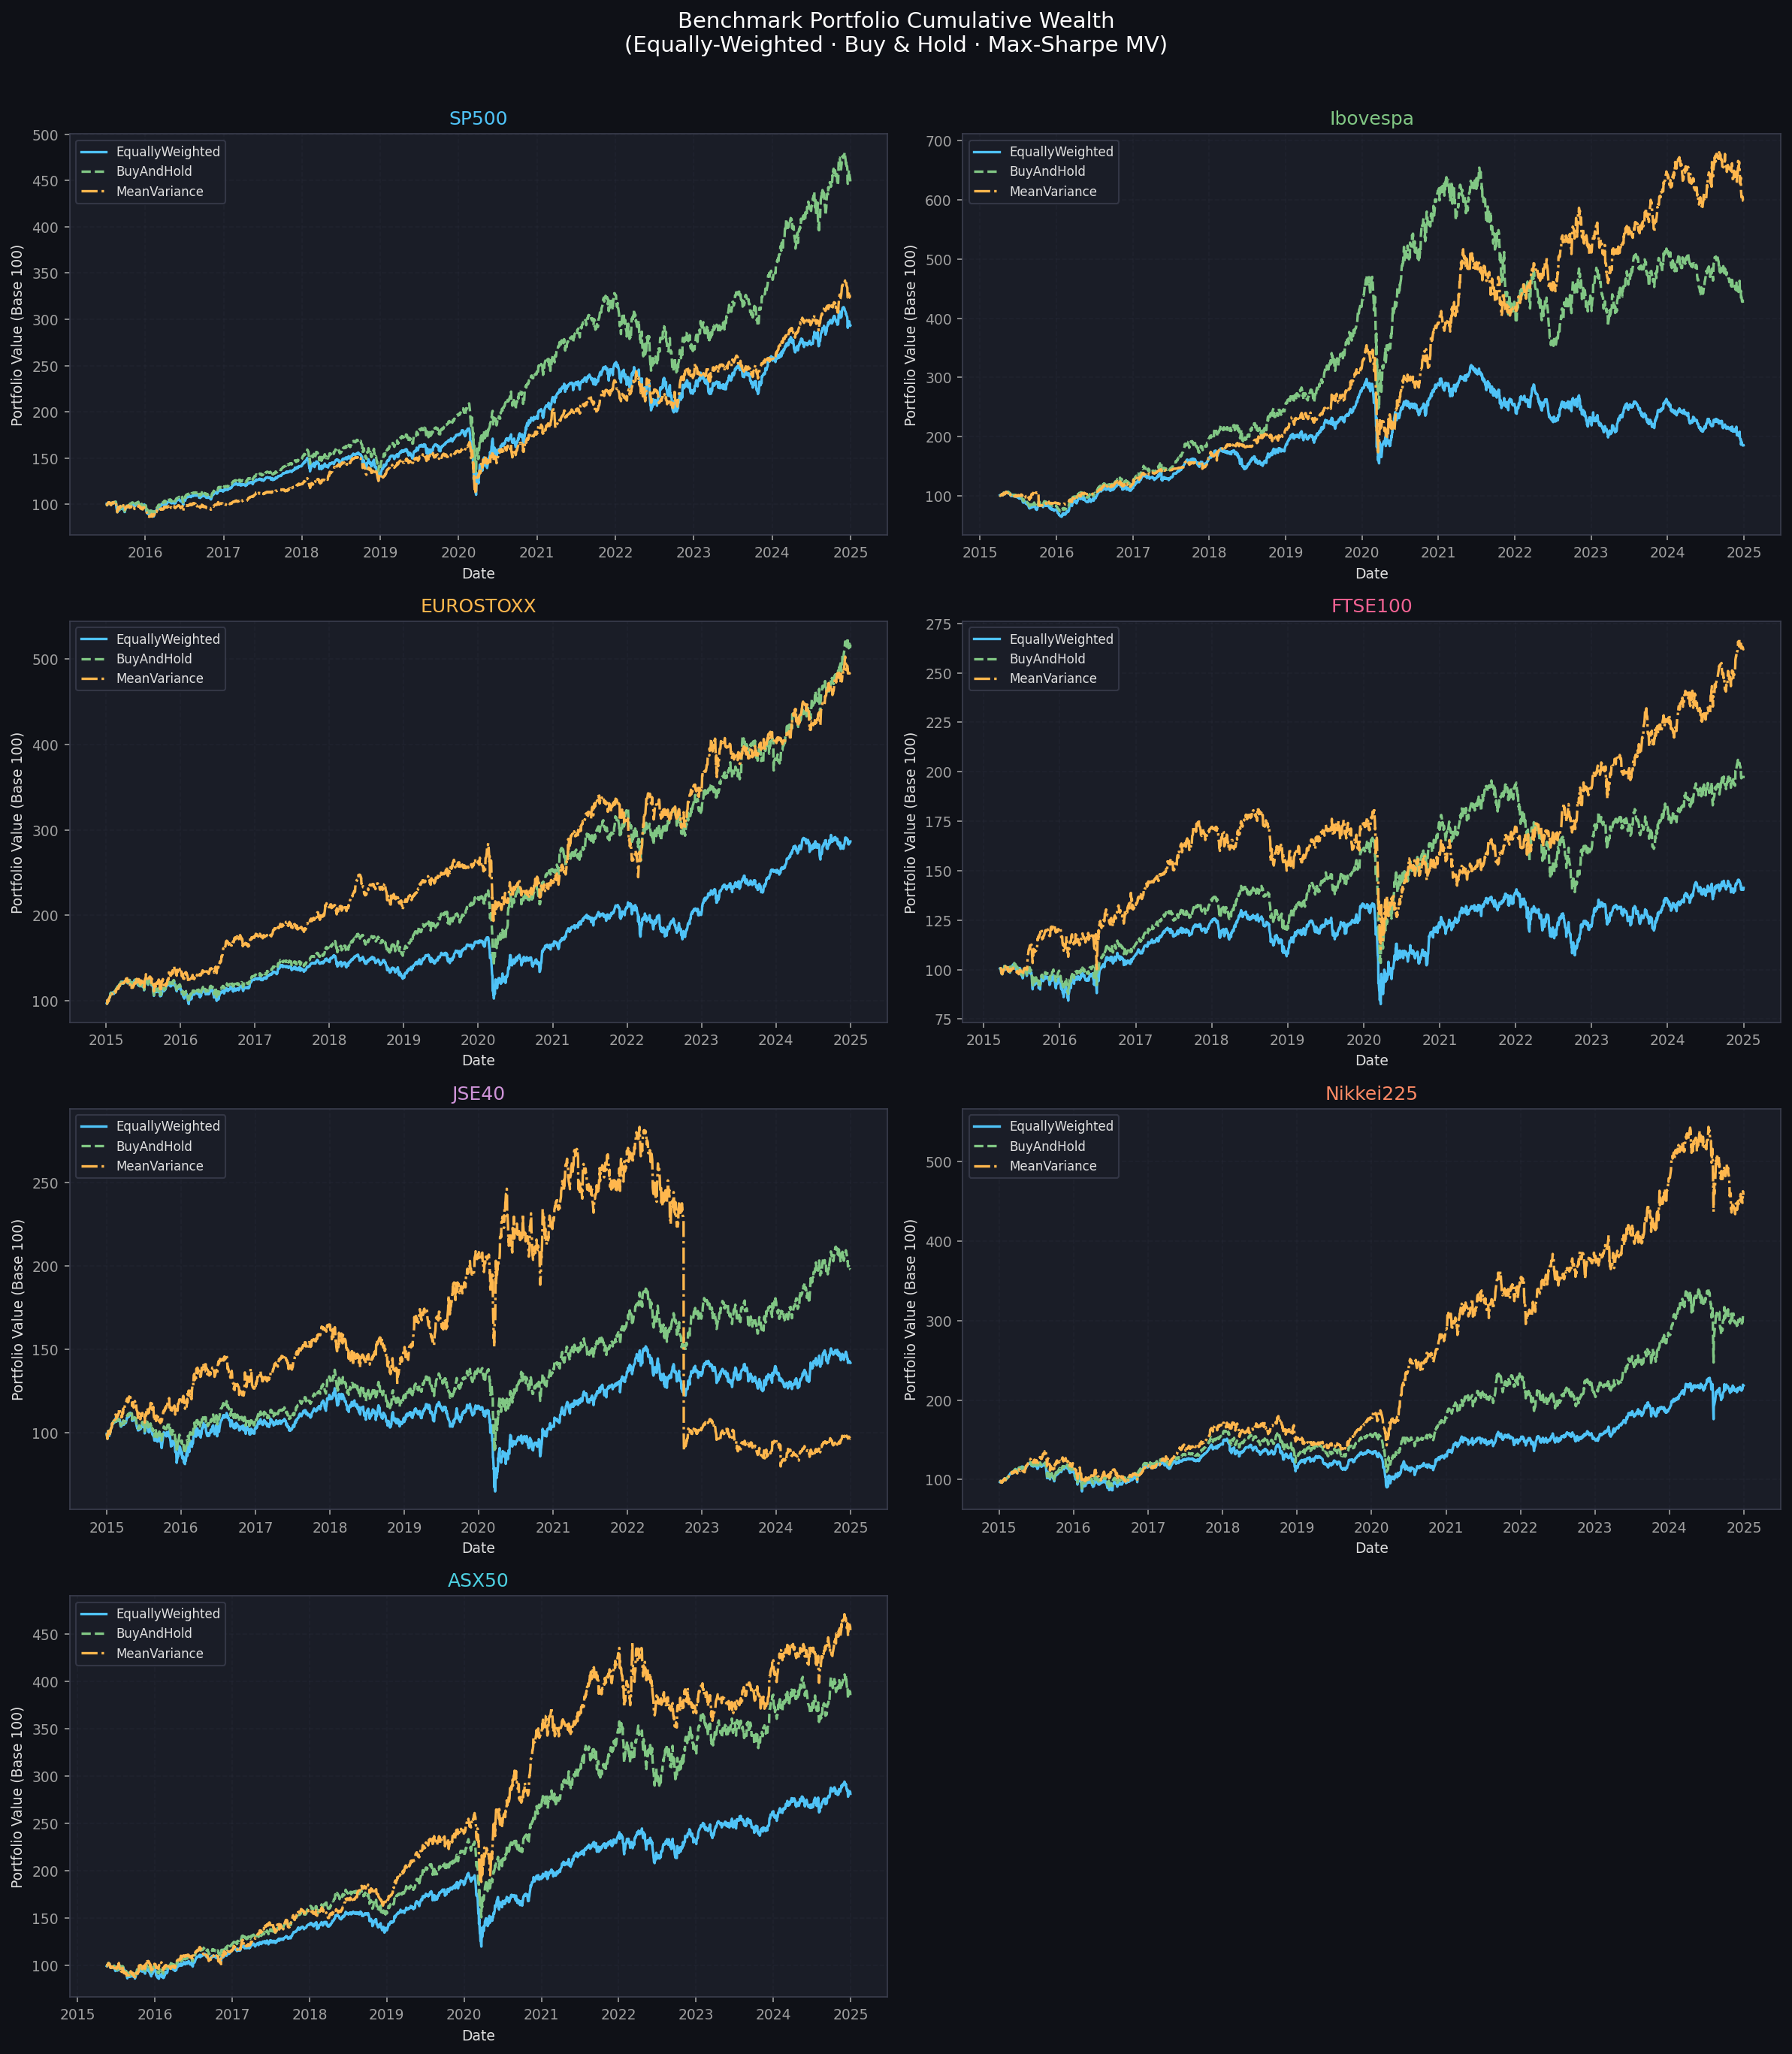

✅  benchmark_cumulative_wealth.png saved.


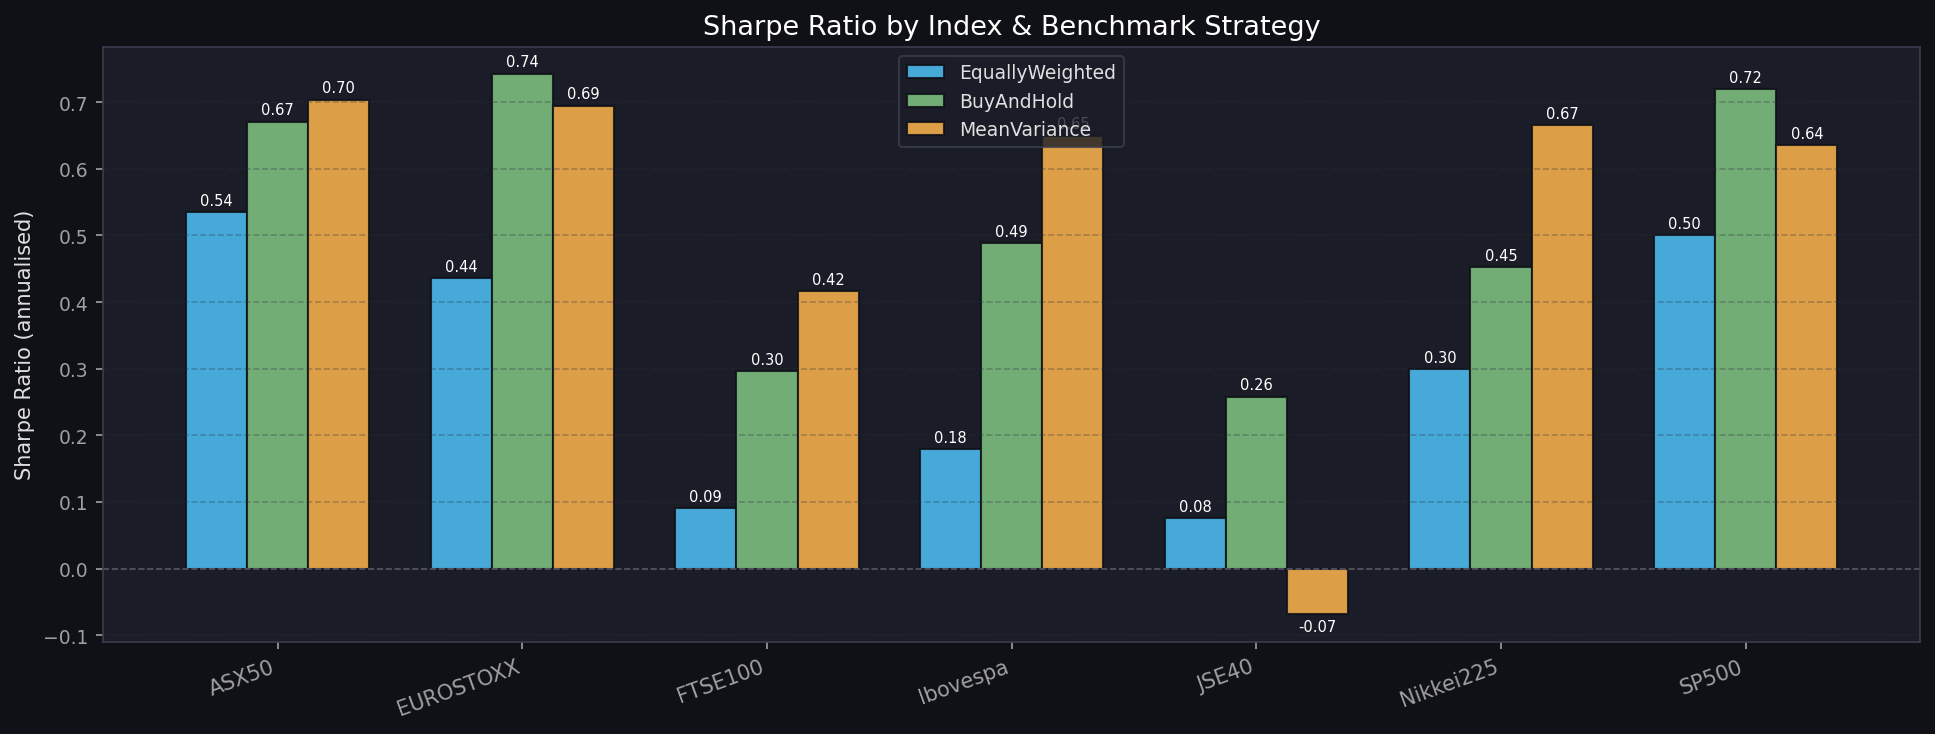

✅  benchmark_sharpe_comparison.png saved.
✅  benchmark_metrics.csv saved.

All benchmark computations complete.


In [ ]:
# ============================================================
# BENCHMARK PORTFOLIOS
# 1. Equally-Weighted Portfolio (EW)
# 2. Buy & Hold Portfolio (B&H)
# 3. Mean-Variance Portfolio (MV) — Max Sharpe
# ============================================================
#
# Assumes the following already exist in the notebook namespace:
#   index_data  : dict[str, pd.DataFrame]  — clean close prices per index
#   FULL_START  : str  e.g. '2015-01-01'
#   FULL_END    : str  e.g. '2025-12-31'
#   INDEX_COLORS: dict[str, str]
#   temporal_split(df, train_ratio, val_ratio) -> (train, val, test)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

TRADING_DAYS = 252
RISK_FREE_RATE = 0.02          # 2 % annual risk-free proxy
REBALANCE_FREQ = "ME"          # Monthly-End rebalancing for EW & MV
MV_LOOKBACK = 60               # trading days for covariance estimation


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: build a single returns DataFrame for one index
# ─────────────────────────────────────────────────────────────────────────────

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")


# ─────────────────────────────────────────────────────────────────────────────
# 1.  EQUALLY-WEIGHTED PORTFOLIO
# ─────────────────────────────────────────────────────────────────────────────

def equally_weighted_portfolio(price_df: pd.DataFrame,
                                rebalance_freq: str = REBALANCE_FREQ
                                ) -> pd.Series:
    """
    Equally-weighted portfolio with periodic rebalancing.

    At each rebalance date, 1/N weight is assigned to every available ticker.
    Between rebalances, weights drift with prices (buy-and-drift).

    Returns
    -------
    pd.Series : daily portfolio log-return
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]
    weights_const = np.ones(n_assets) / n_assets

    # Vectorised: just a simple mean of log returns each day
    port_ret = lr.mean(axis=1)
    port_ret.name = "EW"
    return port_ret


# ─────────────────────────────────────────────────────────────────────────────
# 2.  BUY & HOLD PORTFOLIO
# ─────────────────────────────────────────────────────────────────────────────

def buy_and_hold_portfolio(price_df: pd.DataFrame) -> pd.Series:
    """
    Buy & Hold: equal allocation on day-1, never rebalance.

    Constructs a synthetic NAV starting at 1, then computes daily log-returns.

    Returns
    -------
    pd.Series : daily portfolio log-return
    """
    # Start with 1/N capital in each stock
    n = price_df.shape[1]
    # Value of each position over time (relative)
    relative_prices = price_df / price_df.iloc[0]         # normalise to 1 at t=0
    nav = relative_prices.sum(axis=1) / n                  # portfolio NAV

    port_ret = np.log(nav / nav.shift(1)).dropna()
    port_ret.name = "BuyHold"
    return port_ret


# ─────────────────────────────────────────────────────────────────────────────
# 3.  MEAN-VARIANCE PORTFOLIO  (Maximum Sharpe)
# ─────────────────────────────────────────────────────────────────────────────

def _max_sharpe_weights(mean_ret: np.ndarray,
                         cov: np.ndarray,
                         rf: float = RISK_FREE_RATE / TRADING_DAYS
                         ) -> np.ndarray:
    """
    Solve for the tangency (max-Sharpe) portfolio weights.
    Long-only constraint; weights sum to 1.
    Falls back to equal weights on optimisation failure.
    """
    n = len(mean_ret)

    def neg_sharpe(w):
        p_ret = w @ mean_ret
        p_vol = np.sqrt(w @ cov @ w)
        if p_vol < 1e-10:
            return 0.0
        return -(p_ret - rf) / p_vol

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0.0, 1.0)] * n
    w0 = np.ones(n) / n

    result = minimize(
        neg_sharpe, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-9}
    )

    if result.success:
        return result.x
    return w0  # fallback: equal weights


def mean_variance_portfolio(price_df: pd.DataFrame,
                             lookback: int = MV_LOOKBACK,
                             rebalance_freq: str = REBALANCE_FREQ,
                             rf: float = RISK_FREE_RATE / TRADING_DAYS
                             ) -> pd.Series:
    """
    Rolling Maximum-Sharpe (Mean-Variance) portfolio.

    Weights are re-estimated at every rebalance date using the last
    `lookback` trading days of returns. Between rebalance dates the
    portfolio is held fixed (weights expressed in log-return space).

    Returns
    -------
    pd.Series : daily portfolio log-return
    """
    lr = get_log_returns(price_df)

    # Rebalance dates: end of each period within the return index
    rebalance_dates = lr.resample(rebalance_freq).last().index

    port_ret = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(lr.shape[1]) / lr.shape[1]  # start EW

    reb_idx = 0
    for date in lr.index:
        # Check if we've reached the next rebalance date
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Use lookback window ending at (but not including) today
            hist = lr.loc[:date].iloc[-lookback:]
            if hist.shape[0] >= 20:   # need at least 20 obs
                mu = hist.mean().values
                cov = hist.cov().values
                current_weights = _max_sharpe_weights(mu, cov, rf)
            reb_idx += 1

        port_ret.loc[date] = float(current_weights @ lr.loc[date].values)

    port_ret = port_ret.dropna()
    port_ret.name = "MeanVariance"
    return port_ret


# ─────────────────────────────────────────────────────────────────────────────
# PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def performance_metrics(log_ret: pd.Series,
                         rf_annual: float = RISK_FREE_RATE,
                         name: str = "") -> dict:
    """
    Compute standard portfolio performance metrics from daily log-returns.
    """
    ret = log_ret.dropna()
    rf_daily = rf_annual / TRADING_DAYS

    ann_return = ret.mean() * TRADING_DAYS
    ann_vol    = ret.std()  * np.sqrt(TRADING_DAYS)
    sharpe     = (ret.mean() - rf_daily) / ret.std() * np.sqrt(TRADING_DAYS) if ret.std() > 0 else np.nan

    cum_ret    = ret.cumsum().apply(np.exp)         # gross cumulative wealth
    rolling_max = cum_ret.cummax()
    drawdown    = (cum_ret - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    # Sortino (downside vol)
    downside = ret[ret < rf_daily]
    sortino = (ret.mean() - rf_daily) / downside.std() * np.sqrt(TRADING_DAYS) if len(downside) > 1 else np.nan

    total_return = float(cum_ret.iloc[-1] - 1) * 100   # %

    return {
        "Portfolio"       : name or ret.name,
        "Ann. Return (%)" : round(ann_return * 100, 2),
        "Ann. Volatility (%)": round(ann_vol * 100, 2),
        "Sharpe Ratio"    : round(sharpe, 3),
        "Sortino Ratio"   : round(sortino, 3),
        "Max Drawdown (%)" : round(max_dd * 100, 2),
        "Calmar Ratio"    : round(calmar, 3),
        "Total Return (%)" : round(total_return, 2),
    }


# ─────────────────────────────────────────────────────────────────────────────
# CUMULATIVE WEALTH HELPER
# ─────────────────────────────────────────────────────────────────────────────

def cumulative_wealth(log_ret: pd.Series, start_value: float = 100.0) -> pd.Series:
    """Convert daily log-returns to a cumulative wealth index."""
    return start_value * np.exp(log_ret.cumsum())


# ─────────────────────────────────────────────────────────────────────────────
# MAIN: RUN BENCHMARKS FOR EVERY INDEX
# ─────────────────────────────────────────────────────────────────────────────

benchmark_results = {}   # { index_name : { 'EW': Series, 'BH': Series, 'MV': Series } }
metrics_rows      = []

for idx_name, price_df in index_data.items():
    print(f"\n{'='*55}")
    print(f"  Computing benchmarks for: {idx_name}")
    print(f"{'='*55}")

    # --- compute the three benchmarks ---
    ew_ret = equally_weighted_portfolio(price_df)
    bh_ret = buy_and_hold_portfolio(price_df)
    mv_ret = mean_variance_portfolio(price_df)

    benchmark_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "BuyAndHold"     : bh_ret,
        "MeanVariance"   : mv_ret,
    }

    # --- metrics ---
    for label, ret_series in benchmark_results[idx_name].items():
        m = performance_metrics(ret_series, name=f"{idx_name} — {label}")
        metrics_rows.append(m)
        print(f"  {label:20s}  |  Sharpe={m['Sharpe Ratio']:6.3f}  "
              f"Ann.Ret={m['Ann. Return (%)']:6.2f}%  "
              f"MaxDD={m['Max Drawdown (%)']:6.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# METRICS TABLE
# ─────────────────────────────────────────────────────────────────────────────

metrics_df = pd.DataFrame(metrics_rows).set_index("Portfolio")
print("\n\n" + "="*80)
print("  BENCHMARK PERFORMANCE SUMMARY")
print("="*80)
display(
    metrics_df.style
    .format({
        "Ann. Return (%)": "{:.2f}",
        "Ann. Volatility (%)": "{:.2f}",
        "Sharpe Ratio": "{:.3f}",
        "Sortino Ratio": "{:.3f}",
        "Max Drawdown (%)": "{:.2f}",
        "Calmar Ratio": "{:.3f}",
        "Total Return (%)": "{:.2f}",
    })
    .background_gradient(subset=["Sharpe Ratio", "Calmar Ratio"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown (%)"], cmap="RdYlGn_r")
)

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION: Cumulative wealth per index (3 benchmarks overlaid)
# ─────────────────────────────────────────────────────────────────────────────

n_indices = len(benchmark_results)
ncols = 2
nrows = int(np.ceil(n_indices / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(16, 4.5 * nrows),
                          sharex=False)
axes = np.array(axes).flatten()

BENCH_COLORS = {
    "EquallyWeighted": "#4fc3f7",
    "BuyAndHold"     : "#81c784",
    "MeanVariance"   : "#ffb74d",
}
BENCH_STYLES = {
    "EquallyWeighted": "-",
    "BuyAndHold"     : "--",
    "MeanVariance"   : "-.",
}

for ax_i, (idx_name, bench_dict) in enumerate(benchmark_results.items()):
    ax = axes[ax_i]
    ax.set_facecolor("#1a1d27")

    for label, ret_series in bench_dict.items():
        wealth = cumulative_wealth(ret_series)
        ax.plot(wealth,
                label=label,
                color=BENCH_COLORS[label],
                linestyle=BENCH_STYLES[label],
                linewidth=1.6)

    ax.set_title(idx_name, fontsize=12, color=INDEX_COLORS.get(idx_name, "#ffffff"))
    ax.set_ylabel("Portfolio Value (Base 100)", fontsize=9)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("Date", fontsize=9)

# hide unused subplots
for ax_j in range(n_indices, len(axes)):
    axes[ax_j].set_visible(False)

fig.suptitle("Benchmark Portfolio Cumulative Wealth\n"
             "(Equally-Weighted · Buy & Hold · Max-Sharpe MV)",
             fontsize=14, color="white", y=1.01)
plt.tight_layout()
plt.savefig("benchmark_cumulative_wealth.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅  benchmark_cumulative_wealth.png saved.")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION: Sharpe Ratio comparison bar chart
# ─────────────────────────────────────────────────────────────────────────────

sharpe_pivot = (
    metrics_df["Sharpe Ratio"]
    .reset_index()
    .assign(
        Index     = lambda d: d["Portfolio"].str.split(" — ").str[0],
        Benchmark = lambda d: d["Portfolio"].str.split(" — ").str[1],
    )
    .pivot(index="Index", columns="Benchmark", values="Sharpe Ratio")
)

fig2, ax2 = plt.subplots(figsize=(13, 5))
ax2.set_facecolor("#1a1d27")

x = np.arange(len(sharpe_pivot))
width = 0.25
bench_cols = ["EquallyWeighted", "BuyAndHold", "MeanVariance"]

for i, col in enumerate(bench_cols):
    if col in sharpe_pivot.columns:
        bars = ax2.bar(x + i * width,
                       sharpe_pivot[col],
                       width,
                       label=col,
                       color=BENCH_COLORS[col],
                       alpha=0.85,
                       edgecolor="#0f1117")
        ax2.bar_label(bars, fmt="%.2f", fontsize=7, color="white", padding=2)

ax2.set_xticks(x + width)
ax2.set_xticklabels(sharpe_pivot.index, rotation=20, ha="right", fontsize=10)
ax2.set_ylabel("Sharpe Ratio (annualised)", fontsize=10)
ax2.set_title("Sharpe Ratio by Index & Benchmark Strategy", fontsize=13, color="white")
ax2.axhline(0, color="#555566", linewidth=0.8, linestyle="--")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_sharpe_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅  benchmark_sharpe_comparison.png saved.")

# ─────────────────────────────────────────────────────────────────────────────
# EXPORT metrics to CSV
# ─────────────────────────────────────────────────────────────────────────────

metrics_df.to_csv("benchmark_metrics.csv")
print("✅  benchmark_metrics.csv saved.")
print("\nAll benchmark computations complete.")